#Importing Libraries


In [60]:
import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns

#Loading Dataset

In [61]:
url = "https://raw.githubusercontent.com/Nithinshibu07/Customer-Churn-Prediction/main/data/raw/Telco_customer_churn.xlsx"
df=pd.read_excel(url)


In [62]:
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


#Data Understanding

In [63]:
print("Shape of dataset -",df.shape)

Shape of dataset - (7043, 33)


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [65]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


#Missing Values Analysis

In [66]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

,0
Churn Reason,5174


In [67]:
missing_percent = (df.isnull().sum()/len(df))*100

missing_percent = missing_percent[missing_percent > 0]

missing_percent.sort_values(ascending=False)

,0
Churn Reason,73.463013


#Duplicate Records

In [68]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


# Exploratory Data Analysis (EDA)


###Churn Distribution

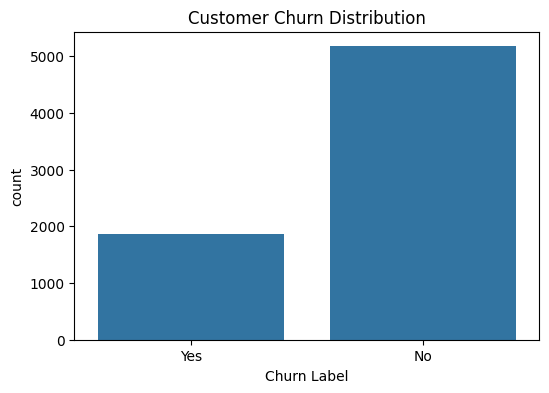

In [69]:


plt.figure(figsize=(6,4))

sns.countplot(x="Churn Label",data=df)

plt.title("Customer Churn Distribution")
plt.show()

##Churn Percentage Distribution

In [70]:
churn_percentage = round( df["Churn Label"].value_counts(normalize=True)*100,2
)

churn_percentage

,proportion
Churn Label,
No,73.46
Yes,26.54


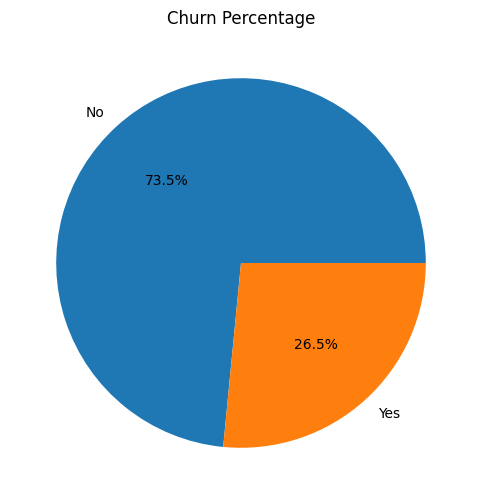

In [71]:
plt.figure(figsize=(6,6))

df["Churn Label"].value_counts().plot(kind="pie",
  autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Churn Percentage")
plt.show()

In [72]:
num_cols = ["Tenure Months","Monthly Charges","Total Charges","CLTV"]
df[num_cols].describe()

,Tenure Months,Monthly Charges,CLTV
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,4400.295755
std,24.559481,30.090047,1183.057152
min,0.000000,18.250000,2003.000000
25%,9.000000,35.500000,3469.000000
50%,29.000000,70.350000,4527.000000
75%,55.000000,89.850000,5380.500000
max,72.000000,118.750000,6500.000000


## Tenure Analysis


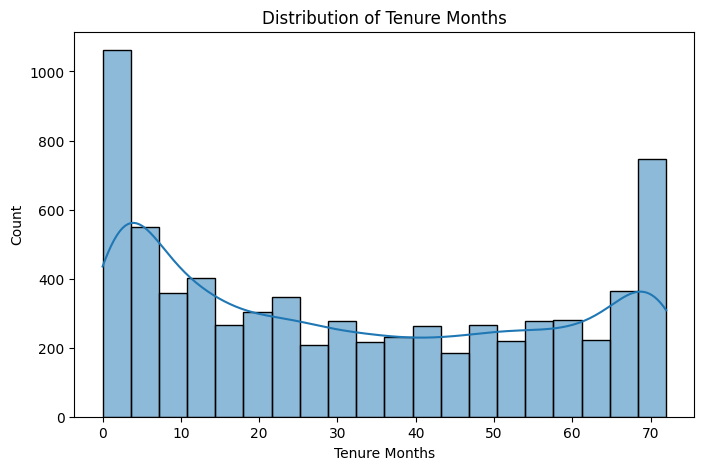

In [73]:
plt.figure(figsize=(8,5))

sns.histplot(df["Tenure Months"],bins=20,kde=True)

plt.title("Distribution of Tenure Months")
plt.show()

## Monthly Charges Analysis

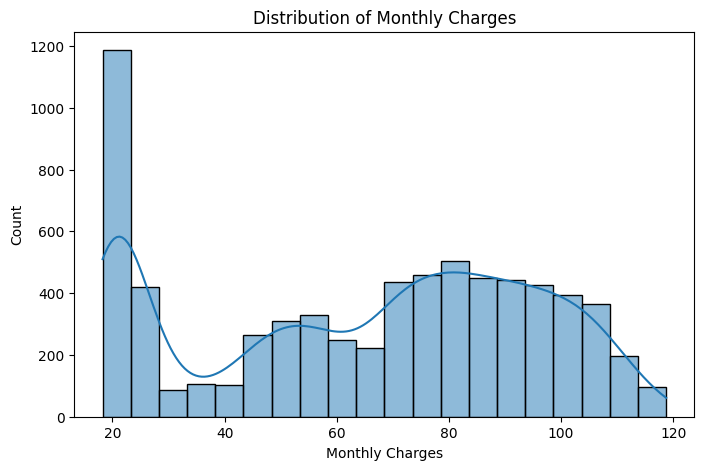

In [74]:
plt.figure(figsize=(8,5))

sns.histplot(df["Monthly Charges"],bins=20,kde=True)

plt.title("Distribution of Monthly Charges")
plt.show()

## Tenure Months vs Churn

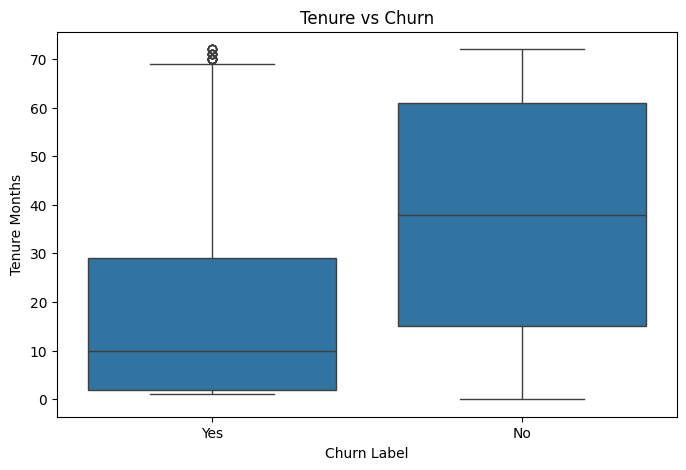

In [75]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn Label",y="Tenure Months",data=df)

plt.title("Tenure vs Churn")
plt.show()

##Monthly Charges Analysis

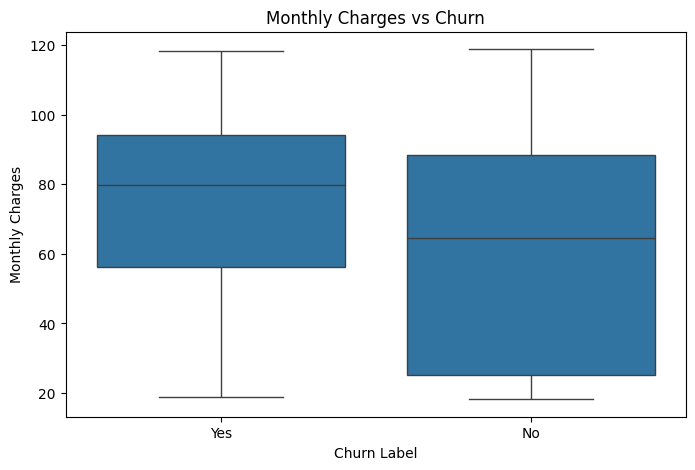

In [76]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn Label",y="Monthly Charges",data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

## Customer Lifetime Value (CLTV) vs Churn

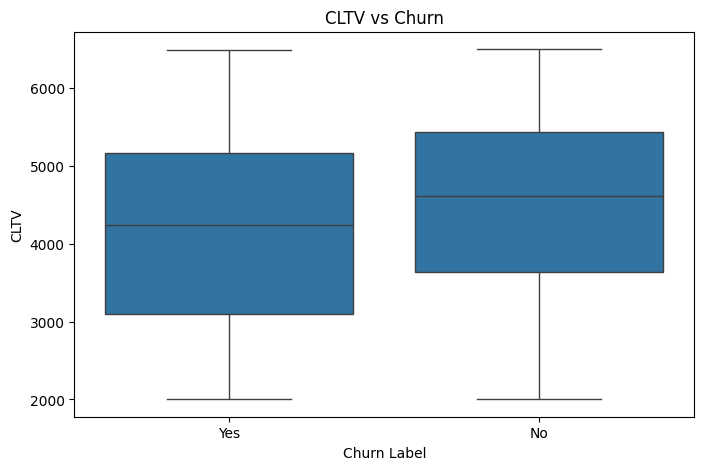

In [77]:
plt.figure(figsize=(8,5))

sns.boxplot(x="Churn Label",y="CLTV",data=df)

plt.title("CLTV vs Churn")
plt.show()

## Contract Type vs Churn

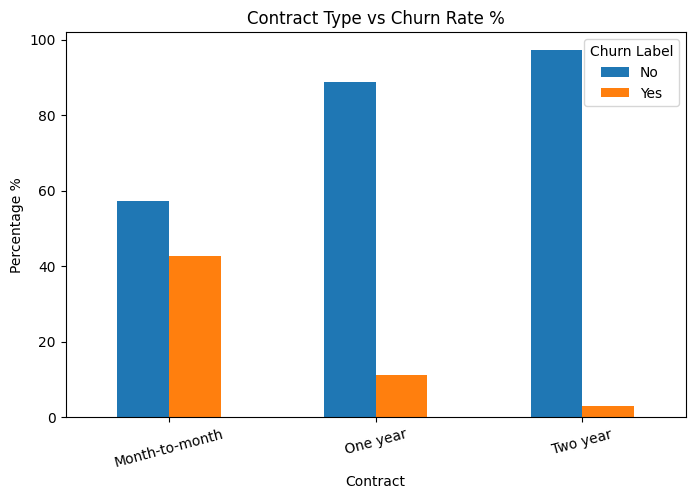

In [78]:
contract_churn = df.groupby('Contract')['Churn Label'].value_counts(normalize=True).mul(100).unstack()
contract_churn.plot(kind='bar', figsize=(8,5))
plt.title('Contract Type vs Churn Rate %')
plt.ylabel('Percentage %')
plt.xticks(rotation=15)
plt.show()

##Internet Service vs Churn

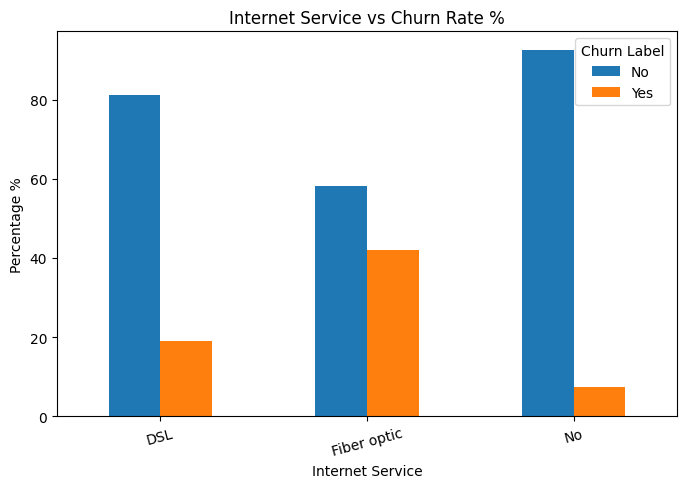

In [79]:
internet_churn = df.groupby('Internet Service')['Churn Label'].value_counts(normalize=True).mul(100).unstack()
internet_churn.plot(kind='bar', figsize=(8,5))
plt.title('Internet Service vs Churn Rate %')
plt.ylabel('Percentage %')
plt.xticks(rotation=15)
plt.show()

In [80]:
numerical_df = df.select_dtypes(include=np.number)

## converting Total Charges column to numeric

In [81]:
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

df['Total Charges'] = df['Total Charges'].fillna(0)

## Correlation Analysis of Numerical Features

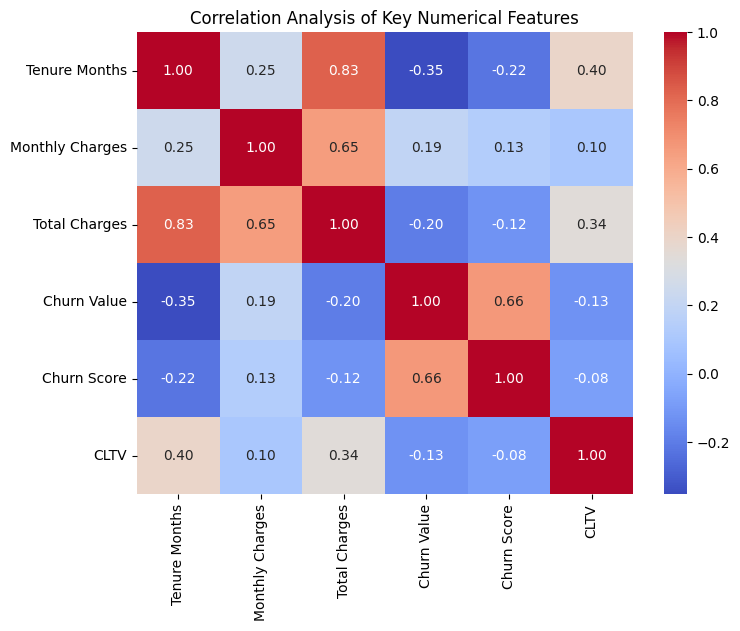

In [82]:
corr_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Value",
    "Churn Score",
    "CLTV"
]


plt.figure(figsize=(8,6))

sns.heatmap(
    df[corr_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Analysis of Key Numerical Features")
plt.show()